# Does a neural network beat a classical model?

A public agency wants to flag likely higher-income households from survey data, so that an outreach programme can be targeted, and it must choose between a simple, explainable model and a more complex neural network. In this project you build both and judge whether the added complexity is worthwhile.

In this project you build two classifiers for the same real data set, then compare them fairly.

**Central question:** does a neural network beat a well-built classical model on this data set?

The data set is Adult, also called Census Income. Each row describes one person, with a mix of numeric features (such as age and hours worked per week) and categorical features (such as occupation and education). The task is to predict whether that person earns more than 50,000 dollars a year.


## Part A. Setup and data


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

import keras
from keras import layers

### Loading the data

I download the Adult data set from OpenML. The features arrive in `X` as a table, and the target in `y` as text, either `>50K` or `<=50K`.

In [2]:
X, y = fetch_openml("adult", version=2, as_frame=True, return_X_y=True)

print("Rows and columns:", X.shape)
print("Target values:", y.value_counts().to_dict())
X.head()

Rows and columns: (48842, 14)
Target values: {'<=50K': 37155, '>50K': 11687}


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


### Encoding the target

The target is text with two values. I convert it to numbers so both models can use it. `LabelEncoder` maps the two classes to 0 and 1 in alphabetical order, so `<=50K` becomes 0 and `>50K` becomes 1. The higher income class is therefore the positive class, labelled 1.

In [3]:
y = LabelEncoder().fit_transform(y)
print("Positive rate (share earning >50K):", round(y.mean(), 3))

Positive rate (share earning >50K): 0.239


### Train and test split

I split the data into a training set and a test set before doing anything else, and keep the class balance with `stratify`. Both models are trained on the training set and judged on the same held-back test set, so the comparison is fair.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training rows:", X_train.shape[0])
print("Test rows:    ", X_test.shape[0])

Training rows: 39073
Test rows:     9769


### Numeric and categorical columns

The two kinds of feature need different preprocessing, therefore I sort the columns into a numeric group and a categorical group.

In [5]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

print("Numeric features:    ", numeric_features)
print("Categorical features:", categorical_features)

Numeric features:     ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


## Part B. The classical model

Building the preprocessing step, where numeric and categorical columns are handled by separate small pipelines, then combined with a ColumnTransformer.

In [6]:
# Preprocessing

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ],
    remainder="drop",)

print("Preprocessor defined.")
print("Numeric columns :", numeric_features)
print("Categorical columns:", categorial_features)

Preprocessor defined.
Numeric columns : ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


### The full pipeline

Wrapping the preprocessor and the logistic regression classifier into a single pipeline.

In [7]:
# Full pipeline
pipe = Pipeline([
    ("preprocess", preprocess),
    ("model",      LogisticRegression(max_iter=1000)),
])

print(pipe)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='

### Cross-validation

Estimating performance by cross-validating on the training data. Relying on a single fold carries uncertainty, therefore I average over several folds to estimate more precise metrics



In [8]:
# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")

print("CROSS-VALIDATION (F1)")
print("-" * 40)
print("Fold scores:", np.round(cv_scores, 4))
print("Mean ± Std: ", np.round(cv_scores.mean(), 4), "±", np.round(cv_scores.std(), 4))

CROSS-VALIDATION (F1)
----------------------------------------
Fold scores: [0.6714 0.6665 0.6528 0.6454 0.6517]
Mean ± Std:  0.6576 ± 0.0098


### Fit and evaluate on the test set

Fitting the pipeline on the training set and judging how it then performs on the test set. This is seen through the F1 score, a confusion matrix and a classification report.

TEST EVALUATION
----------------------------------------
Accuracy: 0.8524
F1 score: 0.6562
Confusion matrix:


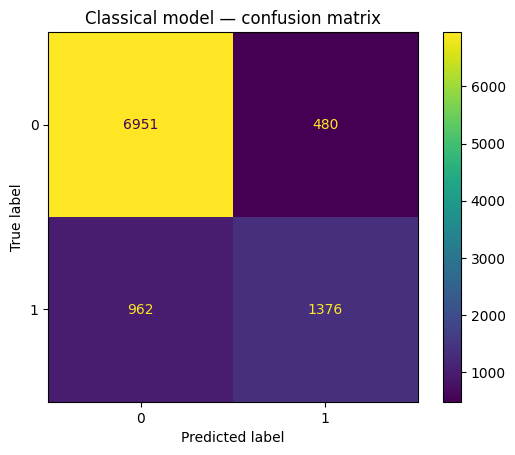

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      7431
           1       0.74      0.59      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.85      0.85      0.85      9769



In [9]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

clf_acc = accuracy_score(y_test, y_pred)
clf_f1 = f1_score(y_test, y_pred)

print("TEST EVALUATION")
print("-" * 40)
print("Accuracy:", round(clf_acc, 4))
print("F1 score:", round(clf_f1, 4))

print("Confusion matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Classical model — confusion matrix")
plt.show()
print("Classification report:")
print(classification_report(y_test, y_pred))

## Part C. The neural network

*(Before moving on, I hypothesize that the neural network will produce similar predictions as the classical model, however it may be better able to limit false positives and/or false negatives. The reasoning is that a neural network is able to optimize itself while a classical model is privy to its original design)*

Here I apply the preprocessor to turn mixed table into numbers. Then fit it on the training set, and only then transform both sets, ensuring no information leaks from the test set.

In [10]:
# Transforming the input to plain numeric array which the neural network needs
X_train_prep = preprocess.fit_transform(X_train)
X_test_prep = preprocess.transform(X_test)

print("Training array shape:", X_train_prep.shape)

Training array shape: (39073, 105)


### Build the network

Building a small dense network for this feature array. The task is binary, so the output is a single unit with a sigmoid activation, giving the probability of the positive class.

In [11]:
# Building the network

net = keras.Sequential([
    layers.Input(shape=(X_train_prep.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),])

net.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,897 (34.75 KB)

 Trainable params: 8,897 (34.75 KB)

 Non-trainable params: 0 (0.00 B)

### Compile and train

Compile and train the network. Because the output is a single sigmoid unit, the loss is `binary_crossentropy`. I use EarlyStopping so training stops once the validation loss stops improving.

In [12]:
# Compile and train

net.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"])


early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,                 # wait 3 epochs with no improvement, then stop
    restore_best_weights=True)   # keep the best model, not the last one)


history = net.fit(
    X_train_prep, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=0)

### Evaluate on the test set

Judge the network on the same test set. The network outputs probabilities, and the threshold for a positive prediction is set above 0.5. Additionaly, Accuracy, F1 score, a confusion matrix and a classification report are provided.

Accuracy: 0.8582
F1 score: 0.6728


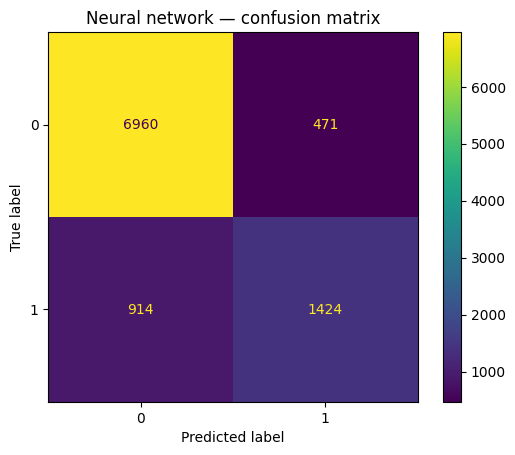

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      7431
           1       0.75      0.61      0.67      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.77      0.79      9769
weighted avg       0.85      0.86      0.85      9769



In [13]:
# Evaluate on test set

proba = net.predict(X_test_prep, verbose=0).ravel()
nn_pred = (proba >= 0.5).astype(int)

nn_acc = accuracy_score(y_test, nn_pred)
nn_f1 = f1_score(y_test, nn_pred)
print("Accuracy:", round(nn_acc, 4))
print("F1 score:", round(nn_f1, 4))

ConfusionMatrixDisplay.from_predictions(y_test, nn_pred)
plt.title("Neural network — confusion matrix")
plt.show()
print("Classification report:")
print(classification_report(y_test, nn_pred))

## Part D. The comparison

Comparing the classical model and the neural network by seeing how they vary on Accuracy, F1 score, and a bar chart vizualising the difference in metrics between models.

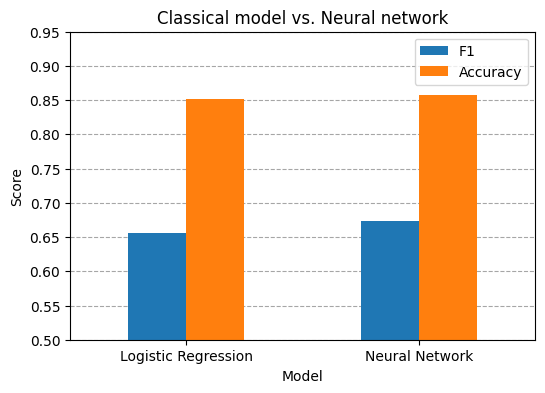

In [14]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Neural Network"],
    "F1": [clf_f1, nn_f1],
    "Accuracy": [clf_acc, nn_acc],
})

ax = comparison.set_index("Model")[["F1", "Accuracy"]].plot.bar(figsize=(6, 4))
ax.set_axisbelow(True)

plt.ylabel("Score")
plt.title("Classical model vs. Neural network")
plt.ylim(0.5, 0.95)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.grid(axis="y", color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
plt.show()

### Ethical considerations

*(If these models performed worse on more vulnareble social groups (which is the case here), the risk is that it will reproduce existing income disparities rather than correcting them. Missing someone who deserves the outreach (false negative) is much more costly than accidentily including someone (false positive), where both models tend to make false negatives, this makes the case for logistic regressions transparency.)*

## Wrapping up

*(The neural network achieved a higher F1 score than logistic regression (0.673 vs. 0.656, a gain of about 1.7 points), and accuracy pointed the same direction (0.858 vs. 0.852). Meaning that both metrics agree on which model is better, even though F1 is the more trustworthy one given the class imbalance (only ~24% of the data belongs to the positive, >50K class). Accuracy alone would understate how well either model is doing on the minority class, where a model that always predicted "≤50K" would already score roughly 76% accuracy while being useless for the actual task of identifying higher earners, so accuracy close to 85% for both models is only a modest improvement over that naive baseline.

The classification reports show both models make more false negatives than false positives (logistic regression: recall of 0.59 on the >50K class; the network: recall of 0.61), indicating that both are more likely to miss a genuine higher earner than to wrongly flag someone. However, the network narrows this gap slightly, correctly identifying more true positives while also being slightly more precise (0.75 vs. 0.74), so it identified the higher-income class more successfully on both fronts, not by trading one error type for the other. Given the network's added training time, tuning surface, and loss of interpretability, this ~1.7-point F1 improvement is real but modest.

The added complexity of the neural network was not justified for this scenario. With such similar performance, the increased intepretability of the classical model is prioritized higher. For instance, answering "why was a specific household flagged?", the logistic regression simply states that the predicted odds went up because of their education, hours worked and so on. While the explanation for the neural network would be that the network's weights decided so.

This is especially true since the threshold-tuning analysis showed most of the achievable F1 gain (~3–4 points) comes from correcting the decision threshold rather than from model choice itself. One plausible reason logistic regression came so close to the network's performance: many of this dataset's strongest predictors (age, education, hours worked, capital gain) relate to income in a fairly linear, additive way, which is exactly the kind of structure a linear model is well-suited to capture — leaving less headroom for a more flexible model to exploit.)*

## Extended analysis

I conduct two robustness analyses to provide insight whether the conclusions hold or are sensitive to subgroup distributions and/or threshold tuning.



To begin I conduct a `Fairness by subgroup` check. Where I primarily breakdown F1 score and accuracy per subgroup, for the model and the network. This allows for a more nuanced perspective on whether specific groups are overrepresented or carrying much of the observed variation.

In [15]:
def subgroup_report(X_test, y_test, y_pred, group_col, model_name, min_n=10):
    print(f"\n{model_name} — performance by {group_col}")
    print("-" * 50)
    rows = []
    for group in X_test[group_col].unique():
        mask = (X_test[group_col] == group).values
        if mask.sum() < min_n:
            continue
        acc = accuracy_score(y_test[mask], y_pred[mask])
        f1  = f1_score(y_test[mask], y_pred[mask])
        rows.append((group, mask.sum(), acc, f1))
        print(f"{group:25s} n={mask.sum():5d}  acc={acc:.3f}  f1={f1:.3f}")
    return pd.DataFrame(rows, columns=[group_col, "n", "accuracy", "f1"])

clf_by_sex  = subgroup_report(X_test, y_test, y_pred,  "sex", "Logistic Regression")
nn_by_sex   = subgroup_report(X_test, y_test, nn_pred, "sex", "Neural Network")
clf_by_race = subgroup_report(X_test, y_test, y_pred,  "race", "Logistic Regression")
nn_by_race  = subgroup_report(X_test, y_test, nn_pred, "race", "Neural Network")


Logistic Regression — performance by sex
--------------------------------------------------
Female                    n= 3259  acc=0.926  f1=0.602
Male                      n= 6510  acc=0.816  f1=0.665

Neural Network — performance by sex
--------------------------------------------------
Female                    n= 3259  acc=0.929  f1=0.627
Male                      n= 6510  acc=0.823  f1=0.681

Logistic Regression — performance by race
--------------------------------------------------
Black                     n=  968  acc=0.908  f1=0.570
White                     n= 8312  acc=0.846  f1=0.663
Asian-Pac-Islander        n=  311  acc=0.826  f1=0.654
Other                     n=   82  acc=0.890  f1=0.400
Amer-Indian-Eskimo        n=   96  acc=0.896  f1=0.444

Neural Network — performance by race
--------------------------------------------------
Black                     n=  968  acc=0.910  f1=0.576
White                     n= 8312  acc=0.852  f1=0.680
Asian-Pac-Islander        n=  3

The second analysis is called `Threshold tuning`, where I sanity check whether the 0.5 cutoff is actually fair to both models, or if it is distorting the comparison, and by consequence the conclusions.

Logistic Regression — best threshold: 0.374, F1: 0.6933 (vs 0.6562 at the default 0.5)
Neural Network — best threshold: 0.301, F1: 0.7025 (vs 0.6728 at the default 0.5)


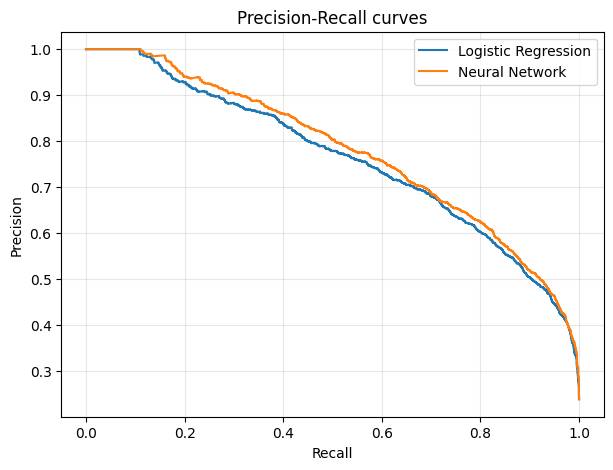

In [16]:
from sklearn.metrics import precision_recall_curve

# Both models threshold their probability output at 0.5 by default, but
# nothing says 0.5 is optimal for F1 specifically. This function scans all
# thresholds the precision-recall curve passes through and picks the one
# that maximizes F1.
def best_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    # +1e-9 avoids a divide-by-zero if precision and recall are both 0
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1s[:-1])   # last point has no matching threshold value
    return thresholds[best_idx], f1s[best_idx]

# Logistic regression's raw probabilities (not yet thresholded)
clf_proba = pipe.predict_proba(X_test)[:, 1]
clf_best_t, clf_best_f1 = best_threshold(y_test, clf_proba)
print(f"Logistic Regression — best threshold: {clf_best_t:.3f}, "
      f"F1: {clf_best_f1:.4f} (vs {clf_f1:.4f} at the default 0.5)")

# `proba` is the network's raw probability output from Part C, before
# it was thresholded into nn_pred
nn_best_t, nn_best_f1 = best_threshold(y_test, proba)
print(f"Neural Network — best threshold: {nn_best_t:.3f}, "
      f"F1: {nn_best_f1:.4f} (vs {nn_f1:.4f} at the default 0.5)")

# Precision-recall curves visualize the full tradeoff space each model
# offers, not just the one point at threshold=0.5
plt.figure(figsize=(7, 5))
for name, p in [("Logistic Regression", clf_proba), ("Neural Network", proba)]:
    prec, rec, _ = precision_recall_curve(y_test, p)
    plt.plot(rec, prec, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()